In [2]:
# Generally whwat we do, we send the whole memory to llm, which will cost us huge.
# So for that, we send only that last few message to the llm.
# So we will trim the last few messages and send it to llm.
# Note: we are not delting the older messages, but in future, for best practice, we will convert
# them in suymmary and replace them with its summary.


In [3]:
from langgraph.graph import StateGraph, START, MessagesState, add_messages,END
from langgraph.checkpoint.sqlite import SqliteSaver
from langgraph.store.sqlite import SqliteStore 
from langchain_openai import ChatOpenAI
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
import os
from pydantic import BaseModel, Field
from typing import Annotated , Optional
from langchain_core.messages.utils import trim_messages,count_tokens_approximately
load_dotenv()

True

In [4]:
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")

MAIN_LLM=ChatOpenAI (
    model= 'gpt-4o-mini',
    temperature=0.3,
    api_key=OPENAI_API_KEY,
    max_retries=3
)

FALLBACK_LLM=ChatGoogleGenerativeAI(
    model= 'gemini-1.5-turbo',
    temperature=0.3,
    api_key=GEMINI_API_KEY,
    max_retries=3
)


llm=MAIN_LLM.with_fallbacks([FALLBACK_LLM])

from langchain_core.callbacks import BaseCallbackHandler
class FallbackTracker(BaseCallbackHandler):
    def on_llm_error(self, error: BaseException, **kwargs) -> None:
        print(f"ChatGPT failed with error: {error}. Falling back to Gemini...")

# Pass the callback handler during invoke
tracker = FallbackTracker()

In [5]:
MAX_TOKENS = 100

In [17]:
class GlobalState(BaseModel):
    messages:Annotated[list, add_messages]=[]
    want_exit:bool = Field(default=None,description="Check if the user want to exit.")
    summary: Optional[str] = Field(default=None,description="Summary of the messages.")

KEY CELL BELOW

In [13]:
def chatmodel(State:GlobalState):

    # ------- trim message -------------------
    messages=trim_messages(
        messages=State.messages,
        max_tokens=MAX_TOKENS,
        strategy="last",                      
        token_counter=count_tokens_approximately
    )
    last_message=State.messages[-1].content
    if "exit" in last_message:
        return {"want_exit":True}

    print('Current Token Count ->', count_tokens_approximately(messages=messages))

    for message in messages:
        print(message)

    res=llm.invoke(messages)
    return {"messages": [("user",res.content)]}

In [8]:
def chatexit(State:GlobalState):
    if State.want_exit == True:
        return "stop"
    else:
        return "continue"

In [9]:

builder=StateGraph(GlobalState)
builder.add_node("chatmodel",chatmodel)


builder.add_edge(START,"chatmodel")
builder.add_conditional_edges(
    "chatmodel",
    chatexit,
    {
        "continue":"chatmodel",
        "stop":END
    }
    
)

In [12]:
with SqliteSaver.from_conn_string("stm2.db") as memory:
    graph=builder.compile(checkpointer=memory)

    config={"configurable":{"thread_id":"stm2_01"}}

    user_input=input()
    events=graph.stream({"messages":[("user", user_input)]},config=config)
    for event in events:
        print(event)

Current Token Count -> 33
content='exit' additional_kwargs={} response_metadata={} id='60fd3ae2-94a1-476b-944d-ff162775a718'
content='hi' additional_kwargs={} response_metadata={} id='e8c6c19a-d54d-48b9-991a-3b1caed4850d'
content='Hello! How can I assist you today?' additional_kwargs={} response_metadata={} id='d155f943-dce0-4011-bf5e-1417368a4311'
content='exit' additional_kwargs={} response_metadata={} id='573e1baa-fe78-498c-a369-8641a5be35e4'
content='hey' additional_kwargs={} response_metadata={} id='9fe4febb-dceb-4ebc-8e40-f44f9d7aebd9'
{'chatmodel': {'messages': [('user', 'Hey there! How can I help you today?')]}}


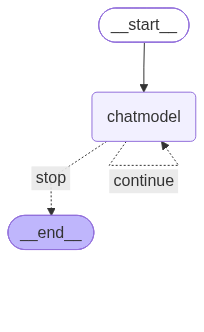

In [16]:
graph